# Oxford-IIIT Pet Dataset Analysis

This notebook performs the initial analysis of the Oxford-IIIT Pet dataset before introducing any neural network model.

The main objectives are:

1. Understand the dataset structure.
2. Verify the 37-class breed classification problem.
3. Understand the official `trainval` / `test` split.
4. Construct a stratified train / validation split.
5. Analyze class distribution.
6. Analyze image resolution and aspect ratio.
7. Inspect representative images and visual variation.
8. Establish the baseline preprocessing pipeline for ResNet-50.
9. Validate the PyTorch Dataset and DataLoader pipeline.

The dataset analysis is the foundation for all later experiments:

```mermaid
flowchart LR
    A["Oxford-IIIT Pet"] --> B["Dataset Analysis"]
    B --> C["ResNet-50 From Scratch"]
    C --> D["Pretrained ResNet-50"]
    D --> E["Feature Extraction"]
    E --> F["Partial Fine-Tuning"]
    F --> G["Full Fine-Tuning"]
    G --> H["Optimization Experiments"]
    H --> I["Evaluation"]
    I --> J["Error Analysis"]

## Environment and Imports

We first import the libraries required for dataset analysis.

The main components are:

- **PyTorch / Torchvision** — dataset handling and tensor operations
- **NumPy / Pandas** — numerical and tabular analysis
- **Matplotlib / Seaborn** — visualization
- **Scikit-learn** — stratified train / validation splitting

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


## Dataset Configuration

The Oxford-IIIT Pet dataset contains 37 pet breed categories.

Torchvision provides a built-in `OxfordIIITPet` dataset implementation, including:

- image loading
- category labels
- official `trainval` split
- official `test` split

In [2]:
DATA_ROOT = Path("../data/raw")

DATA_ROOT.mkdir(parents=True, exist_ok=True)

dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=True
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=True
)

print(f"Official trainval samples: {len(dataset_trainval)}")
print(f"Official test samples: {len(dataset_test)}")
print(f"Number of classes: {len(dataset_trainval.classes)}")

Official trainval samples: 3680
Official test samples: 3669
Number of classes: 37


## Dataset Overview

The official Oxford-IIIT Pet dataset contains:

- **37 breed categories**
- **7,349 images in total**
- **3,680 images in the official `trainval` split**
- **3,669 images in the official `test` split**

For this project, the official test set is not used for model selection.

The experimental split will therefore be:

```mermaid
flowchart TD
    A["Official TrainVal<br/>3,680 images"] --> B["Train"]
    A --> C["Validation"]

    D["Official Test<br/>3,669 images"] --> E["Final Evaluation Only"]

In [3]:
total_samples = len(dataset_trainval) + len(dataset_test)

dataset_summary = pd.DataFrame({
    "Split": [
        "Official Trainval",
        "Official Test",
        "Total"
    ],
    "Samples": [
        len(dataset_trainval),
        len(dataset_test),
        total_samples
    ]
})

dataset_summary

,Split,Samples
0,Official Trainval,3680
1,Official Test,3669
2,Total,7349


## Class Mapping

The target task is **37-class breed classification**.

Each sample follows the mapping:

```mermaid
flowchart LR
    A["Image"] --> B["Integer Class Index"]
    B --> C["Breed Name"]

In [4]:
class_mapping = pd.DataFrame({
    "class_idx": range(len(dataset_trainval.classes)),
    "class_name": dataset_trainval.classes
})

class_mapping

,class_idx,class_name
0,0,Abyssinian
1,1,American Bulldog
2,2,American Pit Bull Terrier
3,3,Basset Hound
4,4,Beagle
5,5,Bengal
6,6,Birman
7,7,Bombay
8,8,Boxer
9,9,British Shorthair


## Sample-Level Label Verification

Before performing aggregate analysis, we verify how an individual sample is represented.

For a given sample:

```mermaid
flowchart LR
    A["Image File"] --> B["PIL Image"]
    B --> C["Integer Label"]
    C --> D["Breed Name"]

In [5]:
image, label = dataset_trainval[0]

print("Image type :", type(image))
print("Image size :", image.size)
print("Label index:", label)
print("Breed      :", dataset_trainval.classes[label])

Image type : <class 'PIL.Image.Image'>
Image size : (394, 500)
Label index: 0
Breed      : Abyssinian


## Class Distribution

We now analyze the number of samples available for each breed.

Class distribution matters because class imbalance can affect:

- optimization
- validation performance
- model selection
- interpretation of accuracy

Even if the dataset is expected to be approximately balanced, we should verify the actual distribution.

In [6]:
trainval_labels = np.array(dataset_trainval._labels)

class_counts = pd.Series(trainval_labels).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_idx": class_counts.index,
    "breed": [
        dataset_trainval.classes[idx] for idx in class_counts.index
    ],
    "count": class_counts.values
})

class_distribution

,class_idx,breed,count
0,0,Abyssinian,100
1,1,American Bulldog,100
2,2,American Pit Bull Terrier,100
3,3,Basset Hound,100
4,4,Beagle,100
5,5,Bengal,100
6,6,Birman,100
7,7,Bombay,96
8,8,Boxer,100
9,9,British Shorthair,100


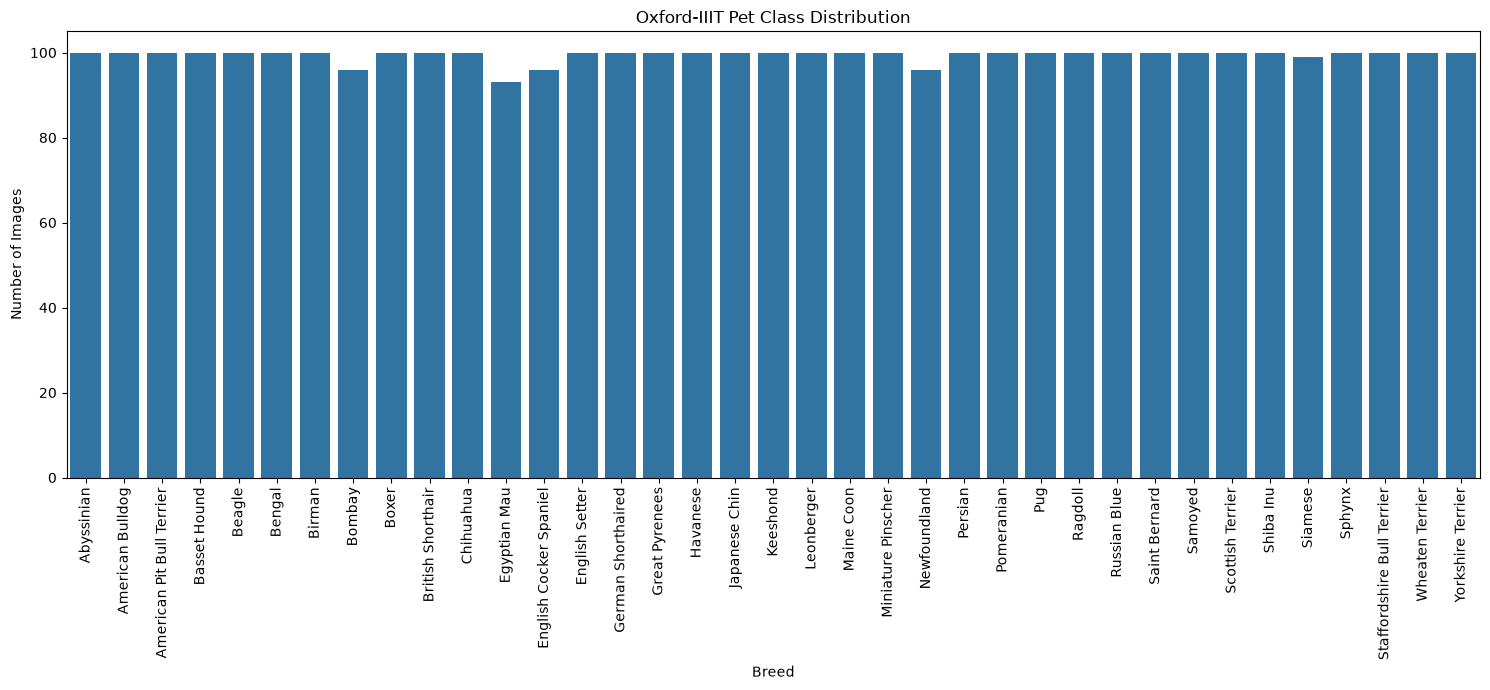

In [7]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=class_distribution,
    x="breed",
    y="count",
)

plt.xticks(rotation=90)
plt.xlabel("Breed")
plt.ylabel("Number of Images")
plt.title("Oxford-IIIT Pet Class Distribution")
plt.tight_layout()
plt.show()

### Observation

The dataset provides a relatively balanced number of images across the 37 breeds.

Therefore, severe class imbalance is not expected to dominate the classification problem.

However, balanced classes do not imply balanced difficulty. Some breeds may remain much harder to distinguish visually than others.

This distinction will become important later when analyzing:

- per-class performance
- confusion matrix
- misclassified samples

## Visual Inspection
### Random Samples

We now inspect the original images before applying any preprocessing.

The purpose is to understand the visual characteristics of the target task:

```mermaid
flowchart TD
    A["Original Images"] --> B["Pose Variation"]
    A --> C["Scale Variation"]
    A --> D["Lighting Variation"]
    A --> E["Background Variation"]
    A --> F["Inter-Class Similarity"]

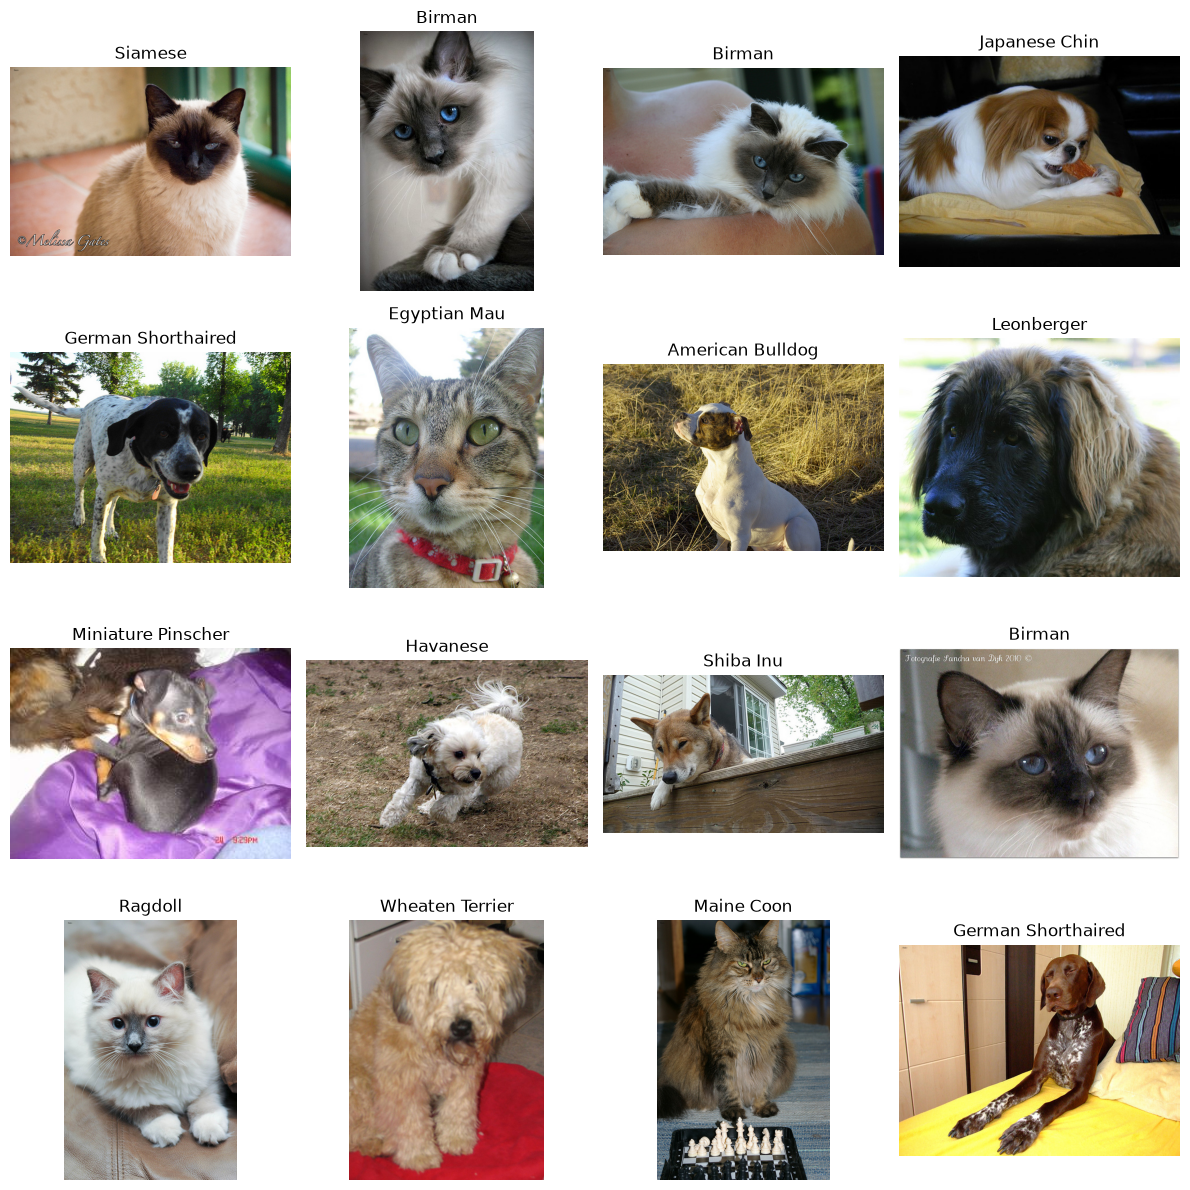

In [8]:
rng = np.random.default_rng(seed=42)

indices = rng.choice(len(dataset_trainval), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, idx in zip(axes.flat, indices):
    image, label = dataset_trainval[idx]

    ax.imshow(image)
    ax.set_title(dataset_trainval.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

### One Sample per Class

Random samples may not cover every category.

Therefore, we select one representative image from each of the 37 breeds.

This gives us a global visual overview of the classification space.

In [9]:
representative_indices = {}

for idx in range(len(dataset_trainval)):
    _, label = dataset_trainval[idx]

    if label not in representative_indices:
        representative_indices[label] = idx

    if len(representative_indices) == len(dataset_trainval.classes):
        break


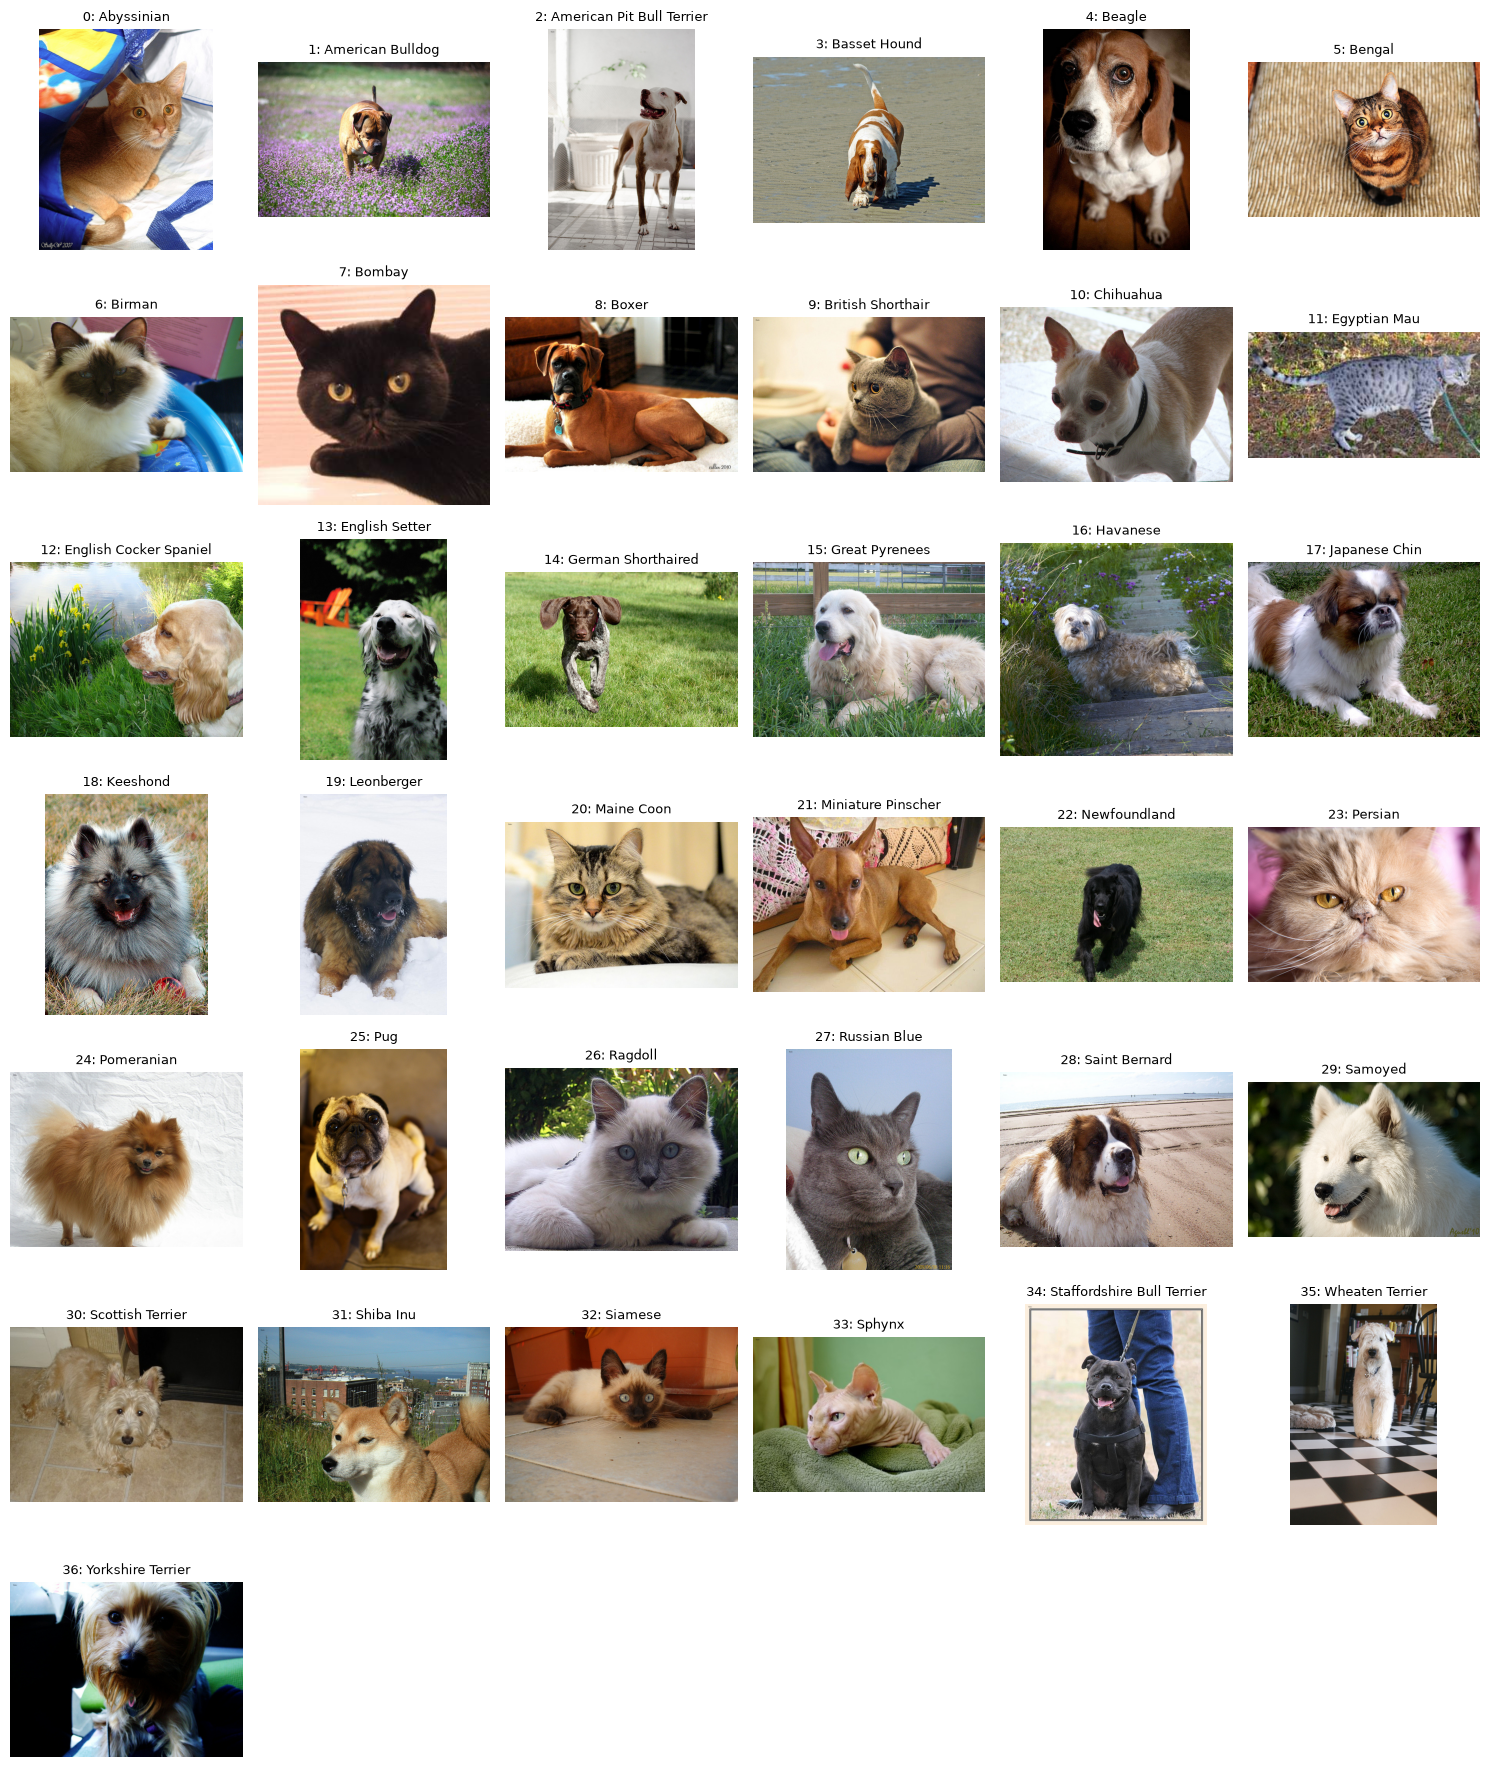

In [10]:
fig, axes = plt.subplots(7, 6, figsize=(15, 18))
axes = axes.flatten()

for class_idx in range(len(dataset_trainval.classes)):
    ax = axes[class_idx]

    image, label = dataset_trainval[
        representative_indices[class_idx]
    ]

    ax.imshow(image)
    ax.set_title(
        f"{class_idx}: {dataset_trainval.classes[class_idx]}",
        fontsize=9,
    )
    ax.axis("off")

for ax in axes[len(dataset_trainval.classes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Image Properties
### Resolution
The original images do not necessarily have identical spatial dimensions.

We analyze:

- width
- height
- aspect ratio

The reason is that ResNet-50 will later receive a fixed spatial input size.

The transformation is conceptually:

```mermaid
flowchart LR
    A["Original Image"] --> B["Variable Resolution"]
    B --> C["Resize / Crop"]
    C --> D["224 × 224"]

In [11]:
image_sizes = []

for idx in range(len(dataset_trainval)):
    image, _ = dataset_trainval[idx]
    
    width, height = image.size

    image_sizes.append({
        "width": width,
        "height": height,
        "aspect_ratio": width / height
    })

image_stats = pd.DataFrame(image_sizes)

image_stats.describe()

,width,height,aspect_ratio
count,3680.000000,3680.000000,3680.000000
mean,431.033424,383.420380,1.176343
std,126.328303,116.833678,0.322537
min,114.000000,108.000000,0.516000
25%,333.000000,333.000000,0.782000
50%,500.000000,375.000000,1.333333
75%,500.000000,500.000000,1.461988
max,3264.000000,2606.000000,2.564103


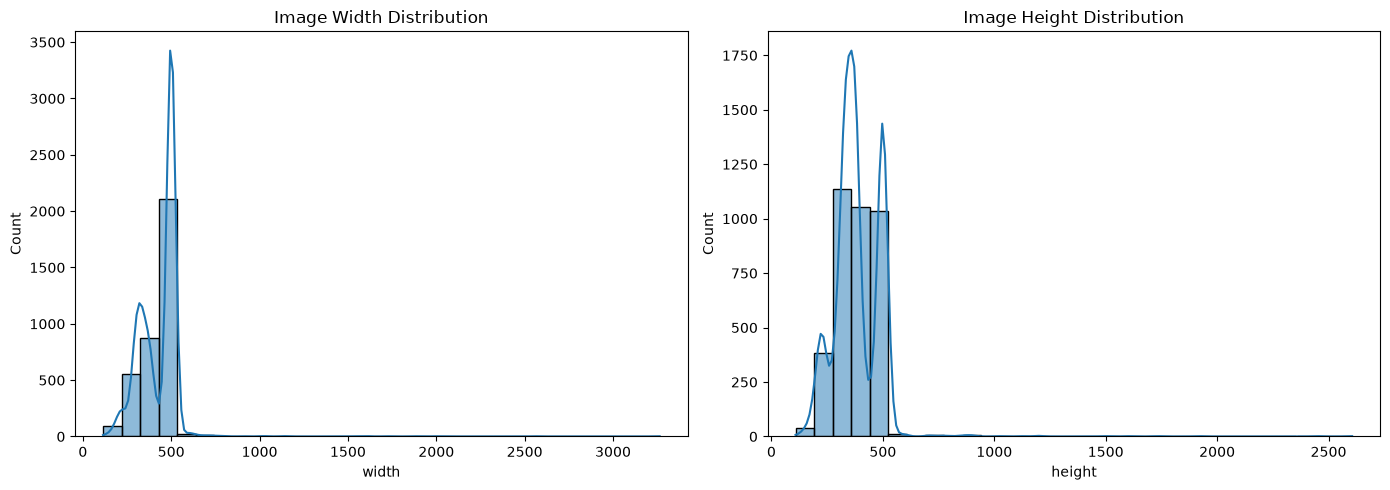

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=image_stats,
    x="width",
    bins=30,
    kde=True,
    ax=axes[0],
)

axes[0].set_title("Image Width Distribution")

sns.histplot(
    data=image_stats,
    x="height",
    bins=30,
    kde=True,
    ax=axes[1],
)

axes[1].set_title("Image Height Distribution")

plt.tight_layout()
plt.show()

### Aspect Ratio

The aspect ratio is defined as:

$$
r = \frac{W}{H}
$$
where:

- $W$ is image width
- $H$ is image height

A value close to 1 indicates a nearly square image.

Because the final CNN input will be square:

$$
224\times224
$$
images with unusual aspect ratios may experience more aggressive cropping or resizing.

This motivates inspecting the aspect-ratio distribution before fixing the preprocessing strategy.

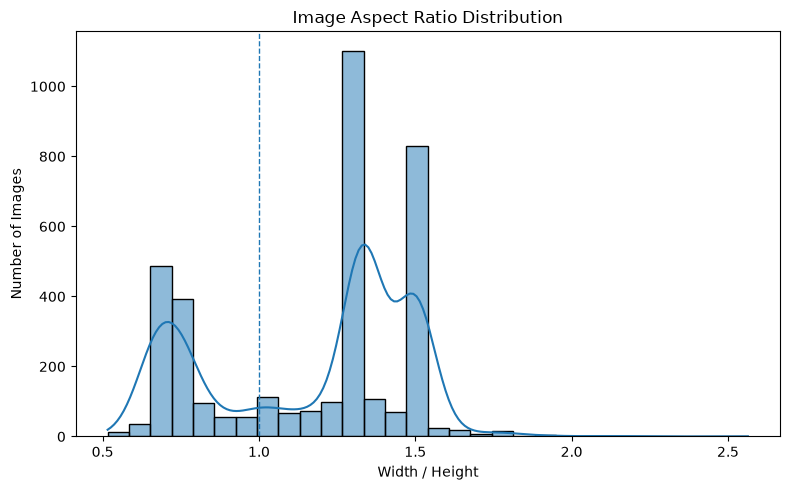

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=image_stats,
    x="aspect_ratio",
    bins=30,
    kde=True,
)

plt.axvline(
    1.0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Width / Height")
plt.ylabel("Number of Images")
plt.title("Image Aspect Ratio Distribution")

plt.tight_layout()
plt.show()

## Official Train / Test Split

The dataset provides two official partitions:

```mermaid
flowchart LR
    A["Oxford-IIIT Pet"] --> B["Official TrainVal"]
    A --> C["Official Test"]

In [14]:
official_split = pd.DataFrame({
    "split": [
        "trainval",
        "test"
    ],
    "count": [
        len(dataset_trainval),
        len(dataset_test)
    ]
})

official_split

,split,count
0,trainval,3680
1,test,3669


## Train / Validation Split

The official `trainval` partition contains 3,680 images.

Because this project contains multiple experiments, a validation set is required for model selection.

We use a stratified 80/20 split:

```mermaid
flowchart TD
    A["Official TrainVal<br/>3,680 images"]
    A --> B["Stratified Split"]

    B --> C["Train<br/>~80%"]
    B --> D["Validation<br/>~20%"]

    C --> E["Optimization"]
    D --> F["Model Selection"]

    G["Official Test<br/>3,669 images"]
    G --> H["Final Evaluation"]

In [15]:
indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"Train samples      : {len(train_indices)}")
print(f"Validation samples : {len(val_indices)}")
print(f"Test samples       : {len(dataset_test)}")


Train samples      : 2944
Validation samples : 736
Test samples       : 3669


## Verify Stratification

For a stratified split, the class proportions should remain approximately similar:

$$
P_{train}(y=k)
\approx
P_{val}(y=k)
$$

We therefore compare the class proportions explicitly.

In [16]:
train_labels = labels[train_indices]
val_labels = labels[val_indices]

train_distribution = (
    pd.Series(train_labels)
    .value_counts(normalize=True)
    .sort_index()
)

val_distribution = (
    pd.Series(val_labels)
    .value_counts(normalize=True)
    .sort_index()
)

split_comparison = pd.DataFrame({
    "train_ratio": train_distribution,
    "validation_ratio": val_distribution,
})

split_comparison["absolute_difference"] = (
    split_comparison["train_ratio"]
    - split_comparison["validation_ratio"]
).abs()

split_comparison

,train_ratio,validation_ratio,absolute_difference
0,0.027174,0.027174,0.000000
1,0.027174,0.027174,0.000000
2,0.027174,0.027174,0.000000
3,0.027174,0.027174,0.000000
4,0.027174,0.027174,0.000000
5,0.027174,0.027174,0.000000
6,0.027174,0.027174,0.000000
7,0.026155,0.025815,0.000340
8,0.027174,0.027174,0.000000
9,0.027174,0.027174,0.000000


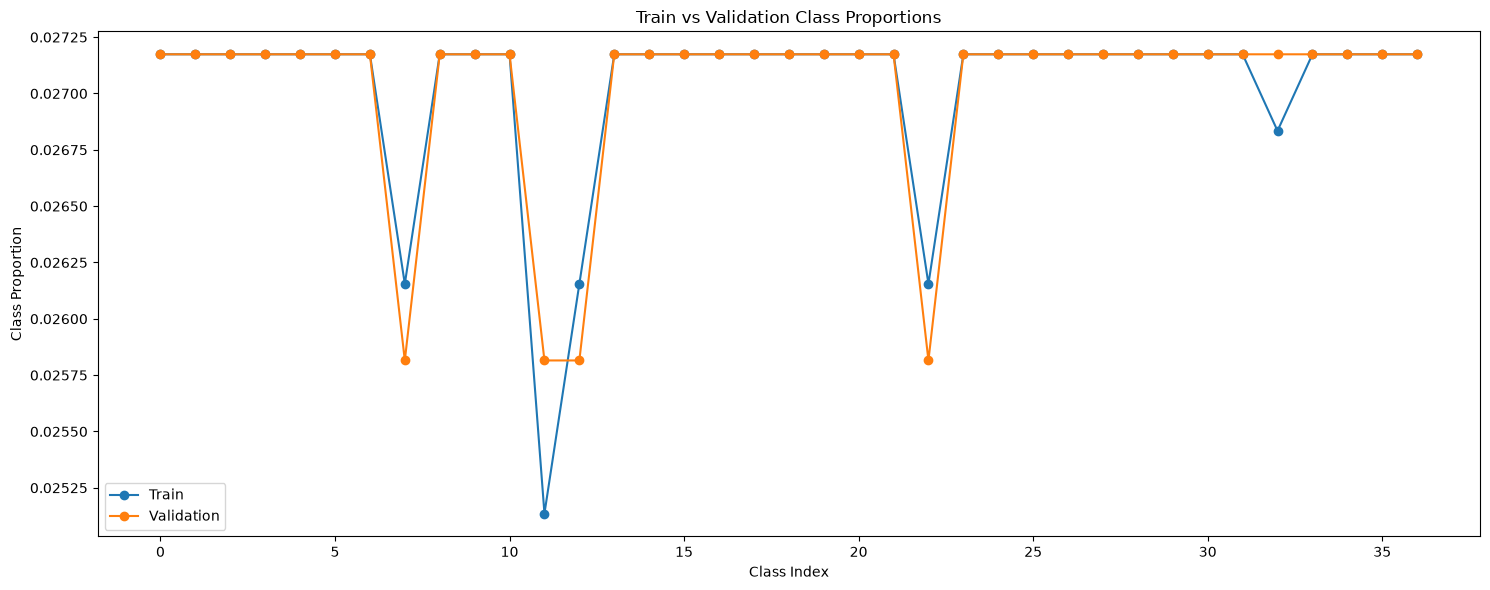

In [17]:
plt.figure(figsize=(15, 6))

plt.plot(
    split_comparison.index,
    split_comparison["train_ratio"],
    marker="o",
    label="Train",
)

plt.plot(
    split_comparison.index,
    split_comparison["validation_ratio"],
    marker="o",
    label="Validation",
)

plt.xlabel("Class Index")
plt.ylabel("Class Proportion")
plt.title("Train vs Validation Class Proportions")
plt.legend()
plt.tight_layout()
plt.show()

## Baseline Transform Pipeline

We now define the baseline image preprocessing strategy.

We intentionally keep augmentation simple at this stage.

### Training pipeline

```mermaid
flowchart LR
    A["Original Image"]
    A --> B["RandomResizedCrop"]
    B --> C["RandomHorizontalFlip"]
    C --> D["ToTensor"]
    D --> E["ImageNet Normalization"]
    E --> F["3 × 224 × 224"]
```

### Validation / Test pipeline

```mermaid
flowchart LR
    A["Original Image"]
    A --> B["Resize"]
    B --> C["CenterCrop"]
    C --> D["ToTensor"]
    D --> E["ImageNet Normalization"]
    E --> F["3 × 224 × 224"]
```

In [18]:
IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


## Inspecting the Training Transform

A preprocessing pipeline should be inspected visually rather than assumed to be correct.

We compare original and transformed images to check whether the transformations preserve the semantic information required for breed classification.

The important question is:

> Does the transformation introduce useful variation without destroying breed-discriminative information?

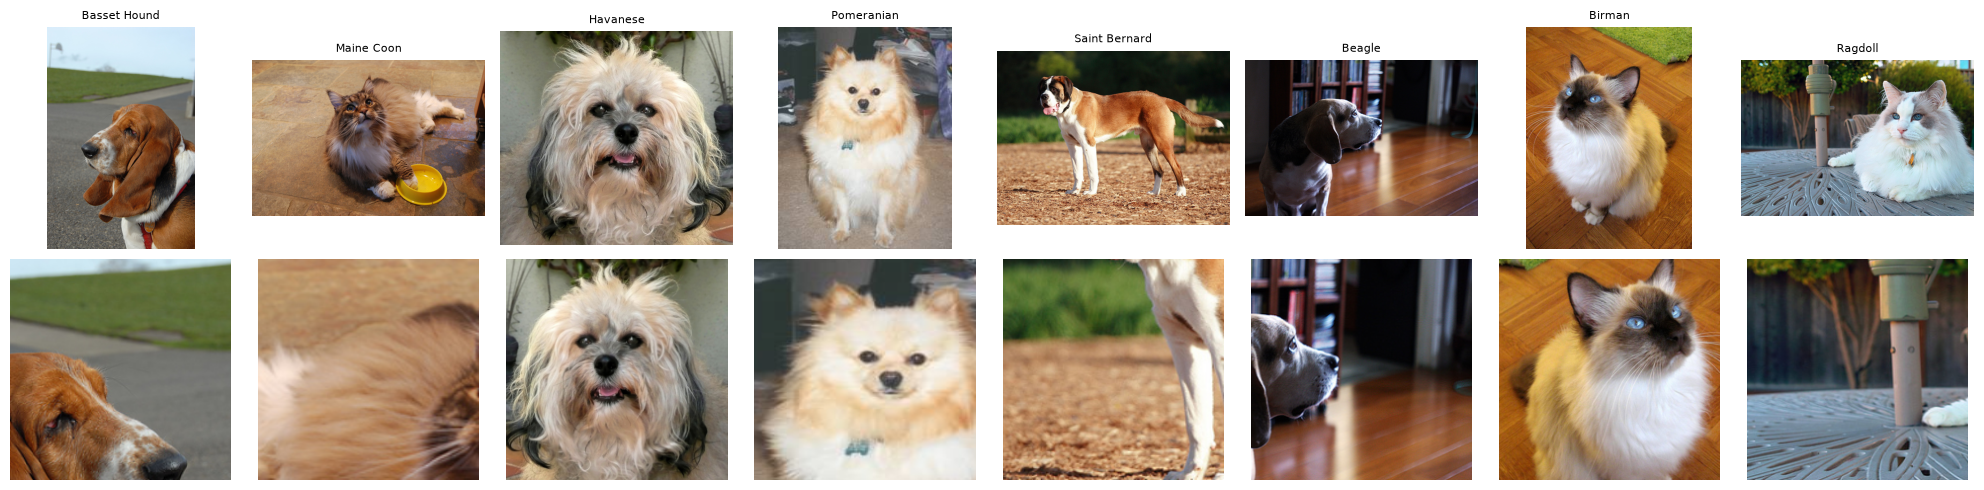

In [19]:
sample_indices = rng.choice(len(dataset_trainval), size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for col, idx in enumerate(sample_indices):
    image, label = dataset_trainval[idx]

    axes[0, col].imshow(image)
    axes[0, col].set_title(dataset_trainval.classes[label], fontsize=8)
    axes[0, col].axis("off")

    transformed = train_transform(image)

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    visualization_image = transformed * std + mean
    visualization_image.clamp_(0, 1)

    axes[1, col].imshow(visualization_image.permute(1, 2, 0))
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Transformed")

plt.tight_layout()
plt.show()

## Train / Validation / Test Dataset Objects

The three subsets share the same underlying images but use different index sets and transformations.

The relationship is:

```mermaid
flowchart TD
    A["Official TrainVal"] --> B["Train Indices"]
    A --> C["Validation Indices"]

    B --> D["Train Dataset"]
    C --> E["Validation Dataset"]

    F["Official Test"] --> G["Test Dataset"]

    D --> H["Training Transform"]
    E --> I["Evaluation Transform"]
    G --> I

In [20]:
class OxfordPetSubset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        transform=None,
    ):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]

        image, label = self.base_dataset[real_idx]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [21]:
train_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=train_indices,
    transform=train_transform
)

val_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=val_indices,
    transform=eval_transform
)

test_dataset = OxfordPetSubset(
    base_dataset=dataset_test,
    indices=np.arange(len(dataset_test)),
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2944
Validation: 736
Test: 3669


## DataLoader Configuration

We now convert the datasets into mini-batches.

The data flow is:

```mermaid
flowchart LR
    A["Dataset"] --> B["DataLoader"]
    B --> C["Mini-Batch"]
    C --> D["CPU Memory"]
    D --> E["CUDA Transfer"]
    E --> F["GPU"]
```

The initial configuration is intentionally conservative:

- Batch size: 32
- `shuffle=True` for training
- `shuffle=False` for validation/test
- `num_workers=2`
- `pin_memory=True` when CUDA is available

In [22]:
BATCH_SIZE = 32
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

## DataLoader Validation

For ResNet-50, the expected input batch is:

$$
X \in \mathbb{R}^{B\times3\times224\times224}
$$
and the target tensor is:

$$
y \in \{0,\ldots,36\}^{B}
$$

We verify these assumptions before introducing the model.

In [23]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)
print("Label min:", labels.min().item())
print("Label max:", labels.max().item())

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels dtype: torch.int64
Label min: 0
Label max: 36


## GPU Pipeline Validation

Before training the first model, we verify that a complete batch can be transferred to the GPU.

This is only a pipeline sanity check.

No model is trained in this notebook.

The data flow is:

```mermaid
flowchart LR
    A["DataLoader Batch"] --> B["CPU Tensor"]
    B --> C["CUDA Transfer"]
    C --> D["GTX 1650"]

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

print("Device:", device)
print("Images:", images.device)
print("Labels:", labels.device)

Device: cuda
Images: cuda:0
Labels: cuda:0


## Final Dataset Pipeline

The complete data pipeline established in this notebook is:

```mermaid
flowchart TD
    A["Oxford-IIIT Pet"] --> B["Official TrainVal / Test"]

    B --> C["Official TrainVal"]
    B --> D["Official Test"]

    C --> E["Stratified Train / Validation Split"]

    E --> F["Train"]
    E --> G["Validation"]

    F --> H["Training Transform"]
    G --> I["Evaluation Transform"]
    D --> I

    H --> J["Train Dataset"]
    I --> K["Validation Dataset"]
    I --> L["Test Dataset"]

    J --> M["Train DataLoader"]
    K --> N["Validation DataLoader"]
    L --> O["Test DataLoader"]

    M --> P["Model Optimization"]
    N --> Q["Model Selection"]
    O --> R["Final Evaluation"]

## Conclusions

The Oxford-IIIT Pet dataset provides a suitable target task for studying Transfer Learning with ResNet-50.

The dataset contains 37 breeds with substantial visual variation. Although the class distribution is relatively balanced, different breeds can still have very different visual difficulty.

The key data-level decisions are:

$$
\boxed{
\text{Understand Data}
\rightarrow
\text{Control the Split}
\rightarrow
\text{Define Preprocessing}
\rightarrow
\text{Validate the Pipeline}
}
$$

The resulting pipeline provides a controlled foundation for the following experiments:

```mermaid
flowchart LR
    A["Data Pipeline"] --> B["E0: Scratch"]
    B --> C["E1: Pretrained"]
    C --> D["E2: Feature Extraction"]
    D --> E["E3/E4: Partial Fine-Tuning"]
    E --> F["E5: Full Fine-Tuning"]
    F --> G["Optimization"]
    G --> H["Evaluation"]
    H --> I["Error Analysis"]